<a href="https://colab.research.google.com/github/Pranav-Codes-Git/Insurance-Company-cost-regression-/blob/main/Another_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



\##### **Project Type**    - Regression
##### **Contribution**    - Individual

##### **Member-** Pranav Deol


# **Project Summary -**

This project focuses on analyzing a personal hospital expenditure dataset to identify the factors that influence medical insurance charges. The dataset contains information such as age, gender, BMI, number of children, smoking status, region, and medical expenses. Exploratory Data Analysis (EDA) is performed using Python libraries like Pandas, Matplotlib, and Seaborn to understand data distribution, identify trends, and visualize relationships between variables.

After preprocessing the data, categorical features are encoded and the dataset is divided into training and testing sets using the train-test split method. Three regression models—Linear Regression, Ridge Regression, and Lasso Regression—are developed to predict medical insurance charges. The models are evaluated using performance metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Cross-validation and hyperparameter tuning are also applied to improve model performance.

The project demonstrates how machine learning can help estimate healthcare costs, identify the most influential factors affecting insurance charges, and support better decision-making for insurance companies and healthcare providers.

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

Medical insurance costs vary significantly from person to person based on factors such as age, BMI, smoking habits, number of children, gender, and region. Predicting these expenses accurately is important for insurance companies to determine premiums and for individuals to estimate future healthcare costs. However, identifying which factors have the greatest impact on medical charges can be challenging.

The objective of this project is to analyze the hospital expenditure dataset, identify the key factors affecting insurance charges through data visualization, and build machine learning regression models—Linear Regression, Ridge Regression, and Lasso Regression—to predict medical expenses. The performance of these models is evaluated using appropriate regression metrics to determine the most accurate model for predicting healthcare costs.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [29]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [30]:
# Load Dataset
df=pd.read_csv('/content/insurance.csv')

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [32]:
# Dataset First Look
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Dataset Rows & Columns count

In [33]:
# Dataset Rows & Columns count

df.shape

(1338, 7)

### Dataset Information

In [34]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### Duplicate Values

In [35]:
# Dataset Duplicate Value Count

df.duplicated().sum()

np.int64(1)

#### Missing Values/Null Values

In [36]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### What did you know about your dataset?

The dataset contains demographic and health-related information such as age, gender, BMI, number of children, smoking status, region, and medical insurance charges.

There are no null values but a single duplicate value which can be dealt in data wrangling section.

Numerical Columns:- Age,BMI,Children,Charges

Categorical Columns:- Sex,Smoker,Region

## ***2. Understanding Your Variables***

In [37]:
# Dataset Columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [38]:
# Dataset Describe
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Variables Description

| Variable     | Description                                                                     |
| ------------ | ------------------------------------------------------------------------------- |
| **age**      | Age of the insured person.                                                      |
| **sex**      | Gender of the insured (Male/Female).                                            |
| **bmi**      | Body Mass Index, indicating body fat based on height and weight.                |
| **children** | Number of dependent children covered by insurance.                              |
| **smoker**   | Indicates whether the insured is a smoker (Yes/No).                             |
| **region**   | Residential region of the insured (Northeast, Northwest, Southeast, Southwest). |
| **charges**  | Medical insurance charges billed to the insured person (Target Variable).       |


### Check Unique Values for each variable.

In [39]:
# Check Unique Values for each variable.
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


## 3. ***Data Wrangling***

### Data Wrangling Code

In [40]:
# Write your code to make your dataset analysis ready.
df_copy = df.copy()
df_copy = df_copy.drop_duplicates()
df_copy.duplicated().sum()

np.int64(0)

In [41]:
df_copy.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [42]:
df_copy.shape

(1337, 7)

### What all manipulations have you done and insights you found?



*  Created a Deep copy of our original dataset to protect raw data
*   Removed a duplicate row by using drop method and verified the shape to see one duplicate row has been removed.

*  No Null values were found in data












## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Gender Distribution

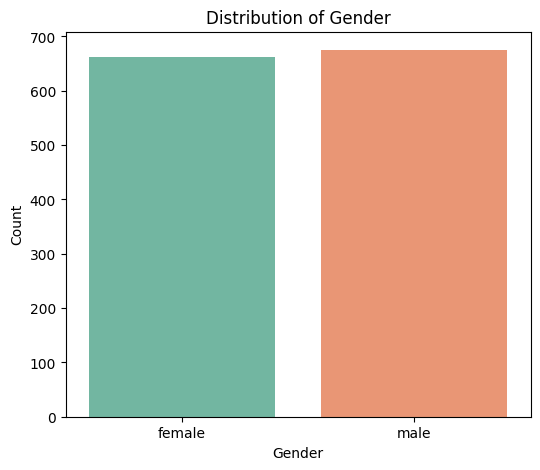

In [43]:
# Chart - 1 visualization code
plt.figure(figsize=(6,5))
sns.countplot(x='sex', data=df_copy, palette='Set2')

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is used to display the frequency of each gender category in the dataset. It provides a simple comparison of the number of male and female policyholders.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

1.   The dataset contains almost an equal number of male and female policyholders.
2.   There is no significant gender imbalance in the dataset.
Both genders are well represented for further analysis.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It also allows insurance companies to compare healthcare expenses across genders without concerns about skewed representation.

#### Chart - 2 : Smoker Distribution

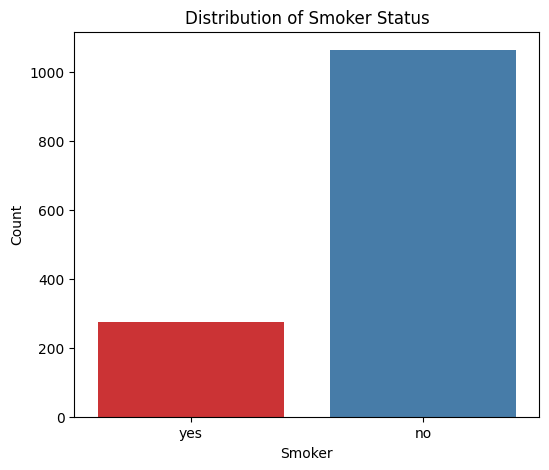

In [44]:
# Chart - 2 visualization code
plt.figure(figsize=(6,5))
sns.countplot(x='smoker', data=df_copy, palette='Set1')

plt.title('Distribution of Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is used to compare the number of smokers and non-smokers in the dataset. It provides a clear view of the distribution of smoking status, which is an important factor influencing medical insurance charges.

##### 2. What is/are the insight(s) found from the chart?

The majority of insured individuals are non-smokers.




Smokers represent a smaller portion of the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Smoking is a major health risk that can significantly increase medical expenses. Understanding the proportion of smokers and non-smokers helps insurance companies assess risk, design suitable premium plans, and evaluate how smoking habits influence healthcare costs.

#### Chart - 3

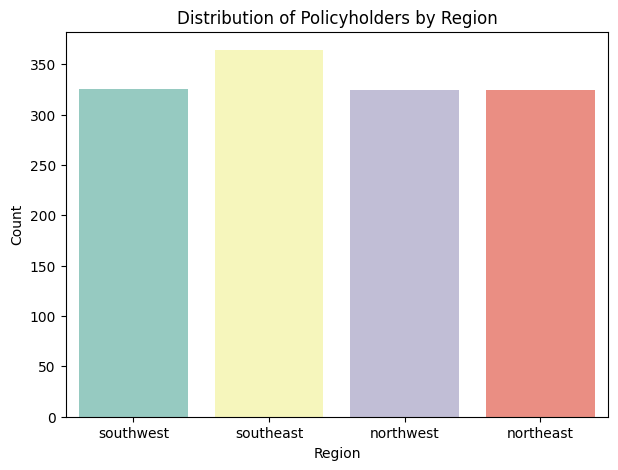

In [45]:
# Chart - 3 visualization code
plt.figure(figsize=(7,5))
sns.countplot(x='region', data=df_copy, palette='Set3')

plt.title('Distribution of Policyholders by Region')
plt.xlabel('Region')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

We can easily compare the distribution of policyholders by various regions using countplot.

##### 2. What is/are the insight(s) found from the chart?



*   The number of policyholders is fairly balanced across all four regions
*   Although Policyholders from Southeast region exceed the policyholders from other regions, no single region is dominating.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A balanced regional distribution helps insurance companies compare healthcare expenses across different locations without bias

#### Chart - 4

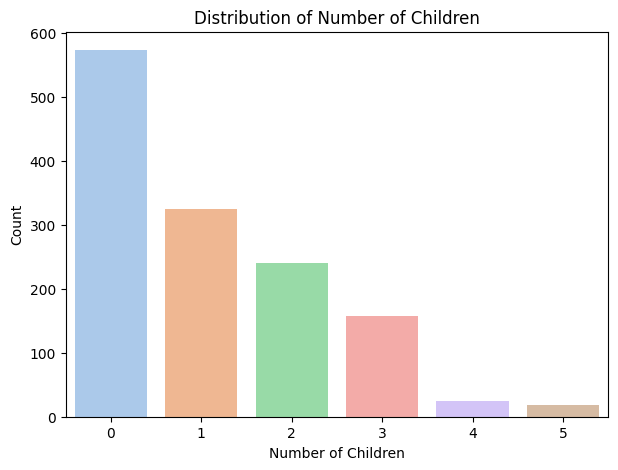

In [46]:
# Chart - 4 visualization code
plt.figure(figsize=(7,5))
sns.countplot(x='children', data=df_copy, palette='pastel')

plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is used to show the frequency of policyholders based on the number of dependent children. It helps identify the most common family sizes represented in the dataset.

##### 2. What is/are the insight(s) found from the chart?



*  Most policyholders have 0 or 1 child.
*   The number of policyholders decreases as the number of children increases.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The number of dependent children may influence healthcare utilization and insurance costs.

Understanding this distribution helps insurance companies design family-oriented insurance plans, estimate healthcare demand, and develop premium structures based on household size.

#### Chart - 5

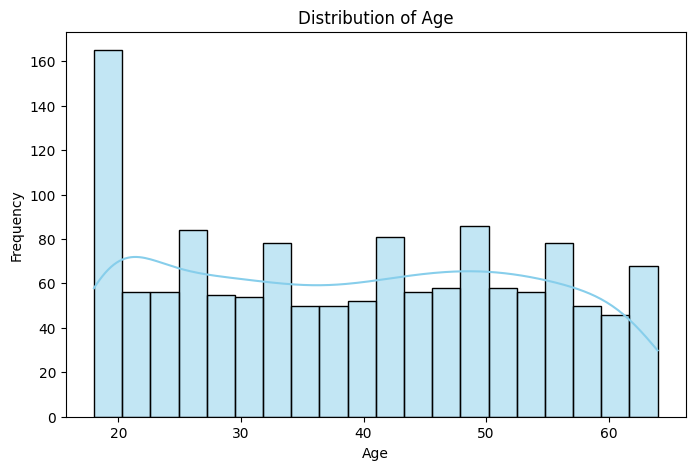

In [47]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df_copy['age'], bins=20,kde=True ,color='skyblue')

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the most suitable chart for displaying the distribution of a continuous numerical variable like age. It helps identify how policyholders are spread across different age groups and whether the data is skewed or evenly distributed.

##### 2. What is/are the insight(s) found from the chart?



*  The ages of policyholders range from 18 to 64 years.
*  The distribution is fairly uniform across different age groups, with a  higher concentration of younger adults.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Analyzing age distribution helps insurance companies understand the composition of their customers, estimate age-related healthcare risks, and design premium plans that are appropriate for different age groups.

#### Chart - 6

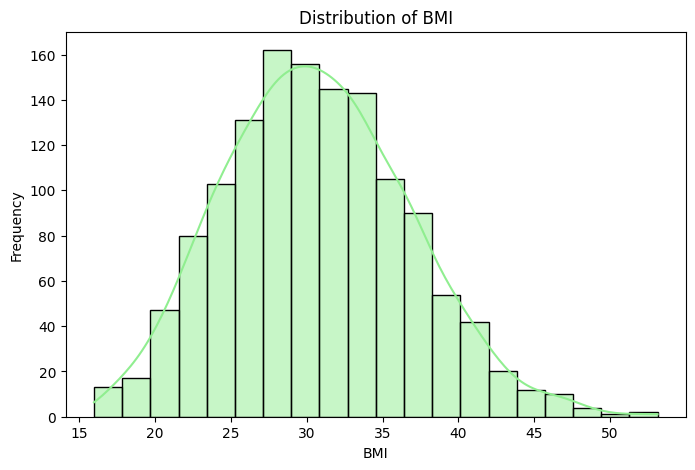

In [48]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df_copy['bmi'], bins=20, kde=True, color='lightgreen')

plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable for visualizing the distribution of a continuous numerical variable like BMI (Body Mass Index). It helps identify the spread of BMI values, the concentration of observations, and whether the data follows a normal distribution.

##### 2. What is/are the insight(s) found from the chart?





* Most policyholders have a BMI between 25 and 35, indicating that a large proportion fall within the overweight category.
*   The BMI values are approximately normally distributed.


*   There are a few individuals with very high BMI values, suggesting possible obesity-related cases.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

BMI is an important indicator of an individual's health and is closely associated with medical expenses. Higher BMI may increase the risk of chronic diseases, leading to higher insurance claims.

#### Chart - 7

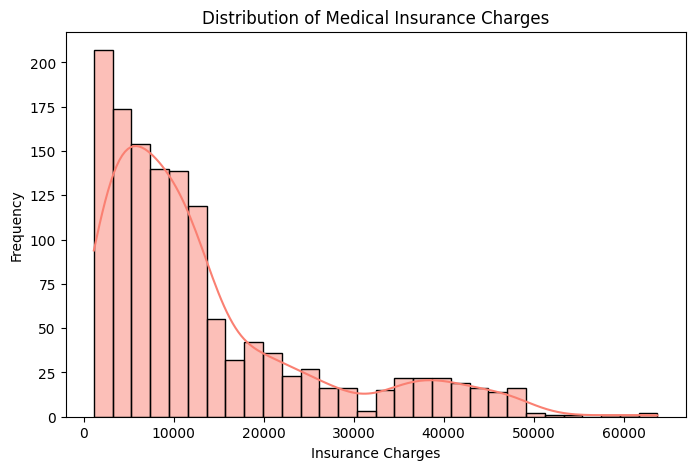

In [49]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df_copy['charges'], bins=30, kde=True, color='salmon')

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Insurance Charges')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

It helps identify the spread of medical expenses, the presence of skewness, and any unusually high insurance charges.

##### 2. What is/are the insight(s) found from the chart?



*  Most policyholders have lower to moderate medical expenses, while a smaller number incur very high charges.
*   The presence of high-value observations indicates potential outliers, likely associated with higher health risks such as smoking or obesity.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This information is useful for premium pricing, financial planning, risk assessment, and designing policies that account for customers with significantly higher healthcare expenses.

#### Chart - 8

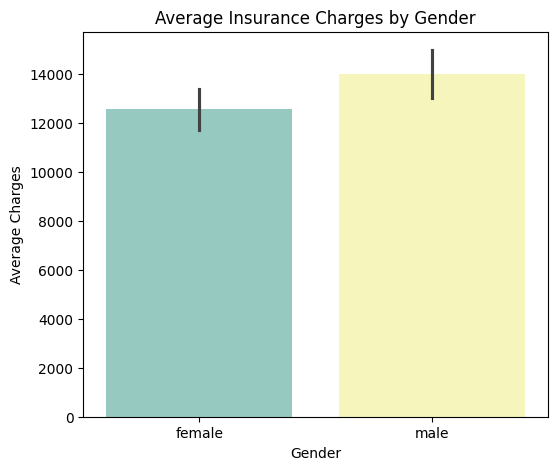

In [50]:
# Chart - 8 visualization code
# Average insurance charges by gender

plt.figure(figsize=(6,5))
sns.barplot(x='sex', y='charges', data=df_copy, palette='Set3')

plt.title('Average Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Charges')

plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is appropriate for comparing the average insurance charges between male and female policyholders. It clearly displays the mean charges for each gender, making comparison straightforward.

##### 2. What is/are the insight(s) found from the chart?



*   Males tend to have slightly higher average medical charges than females.
*   Gender alone does not appear to have a significant impact on insurance charges compared to other factors such as smoking status or BMI.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since the difference is relatively small, insurers should focus more on influential factors like smoking habits, BMI, and age rather than gender when assessing healthcare costs and determining premiums.

#### Chart - 9

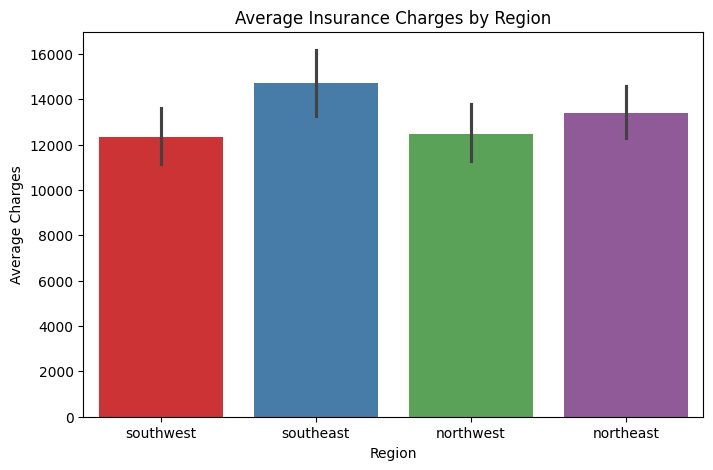

In [51]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='charges', data=df_copy, palette='Set1')

plt.title('Average Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')

plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is used to compare the average insurance charges across different regions. It clearly shows the variation in mean medical expenses among the four geographical regions.

##### 2. What is/are the insight(s) found from the chart?



*   The Southeast region has the highest average insurance charges.
*   Regional differences exist, but they are not as significant as factors like smoking status or BMI.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This information can support regional pricing strategies, resource allocation, and the design of location-specific insurance policies if consistent cost differences are observed.

#### Chart - 10

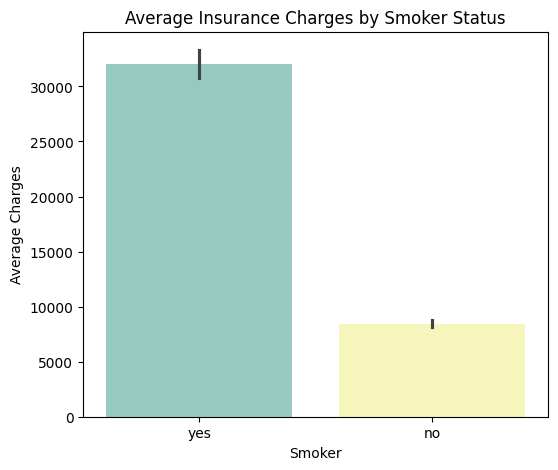

In [52]:
# Chart - 10 visualization code

plt.figure(figsize=(6,5))
sns.barplot(x='smoker', y='charges', data=df_copy, palette='Set3')

plt.title('Average Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Average Charges')

plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is used to compare the average insurance charges of smokers and non-smokers. It clearly highlights the difference in mean medical expenses between the two groups.



##### 2. What is/are the insight(s) found from the chart?



*   Smokers have significantly higher average insurance charges than non-smokers.
*   Smoking appears to be one of the strongest factors affecting medical insurance expenses in the dataset.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insurance companies can use this information to assess health risks, determine premium amounts, promote preventive healthcare programs, and encourage healthier lifestyles through incentive-based insurance policies

#### Chart - 11

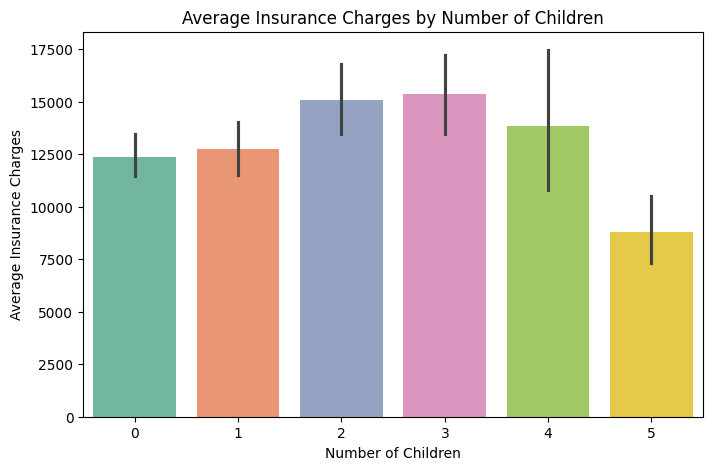

In [53]:
# Chart - 11 visualization code

plt.figure(figsize=(8,5))
sns.barplot(x='children', y='charges', data=df_copy, palette='Set2')

plt.title('Average Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Insurance Charges')

plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is used to compare the average insurance charges across different numbers of dependent children. It clearly shows how medical expenses vary with family size.

##### 2. What is/are the insight(s) found from the chart?

Policyholders with more children tend to have slightly higher average medical expenses, although the increase is not strictly linear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This information can support the design of family insurance plans and assist in estimating premiums for households with different numbers of dependents.

#### Chart - 12

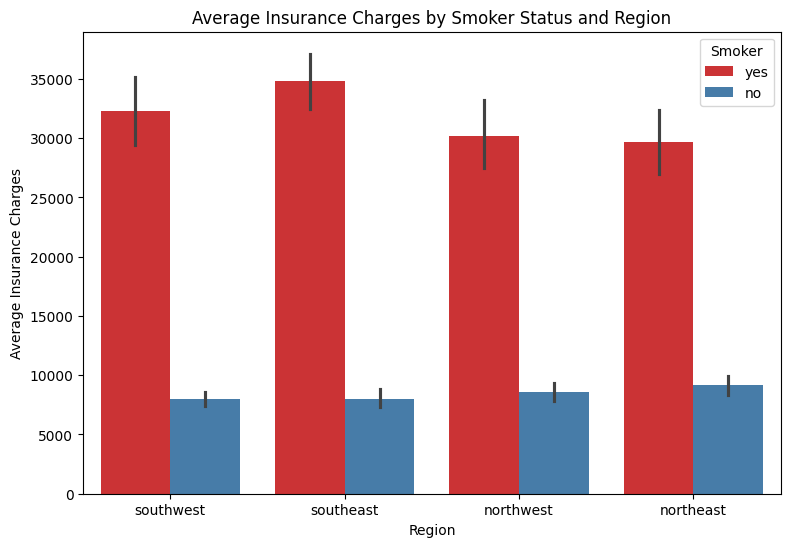

In [54]:
# Chart - 12 visualization code
# Average insurance charges by smoker status and region

plt.figure(figsize=(9,6))

sns.barplot(
    x='region',
    y='charges',
    hue='smoker',
    data=df_copy,
    palette='Set1'
)

plt.title('Average Insurance Charges by Smoker Status and Region')
plt.xlabel('Region')
plt.ylabel('Average Insurance Charges')
plt.legend(title='Smoker')

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar plot is used to compare the average insurance charges across different regions while simultaneously distinguishing between smokers and non-smokers. It enables multivariate analysis by visualizing the combined effect of two categorical variables on insurance charges.

##### 2. What is/are the insight(s) found from the chart?



*   Smokers have significantly higher average insurance charges than non-smokers in every region.

*   The Southeast region generally records the highest average charges, especially among smokers.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It highlights that smoking consistently leads to higher insurance expenses regardless of region, allowing insurers to develop more accurate risk-based pricing and region-specific healthcare strategies.

#### Chart - 13

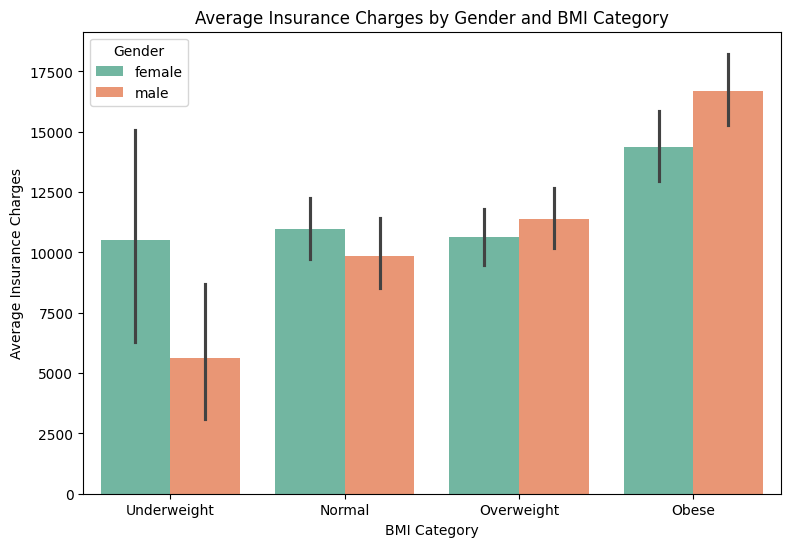

In [55]:
# Chart - 13 visualization code
# Create BMI categories

df_copy['BMI Category'] = pd.cut(
    df_copy['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Plot

plt.figure(figsize=(9,6))

sns.barplot(
    x='BMI Category',
    y='charges',
    hue='sex',
    data=df_copy,
    palette='Set2'
)

plt.title('Average Insurance Charges by Gender and BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Insurance Charges')
plt.legend(title='Gender')

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar plot is used to compare the average insurance charges across different BMI categories while also distinguishing between male and female policyholders. Categorizing BMI makes the visualization more meaningful and easier to interpret than plotting hundreds of individual BMI values.


##### 2. What is/are the insight(s) found from the chart?



* Insurance charges generally increase as BMI moves from Normal to Obese.
*  BMI appears to have a stronger influence on insurance costs than gender.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It highlights that higher BMI is associated with increased medical costs, enabling insurers to design wellness programs, encourage healthier lifestyles, and develop more accurate premium pricing.

#### Chart - 14 - Correlation Heatmap

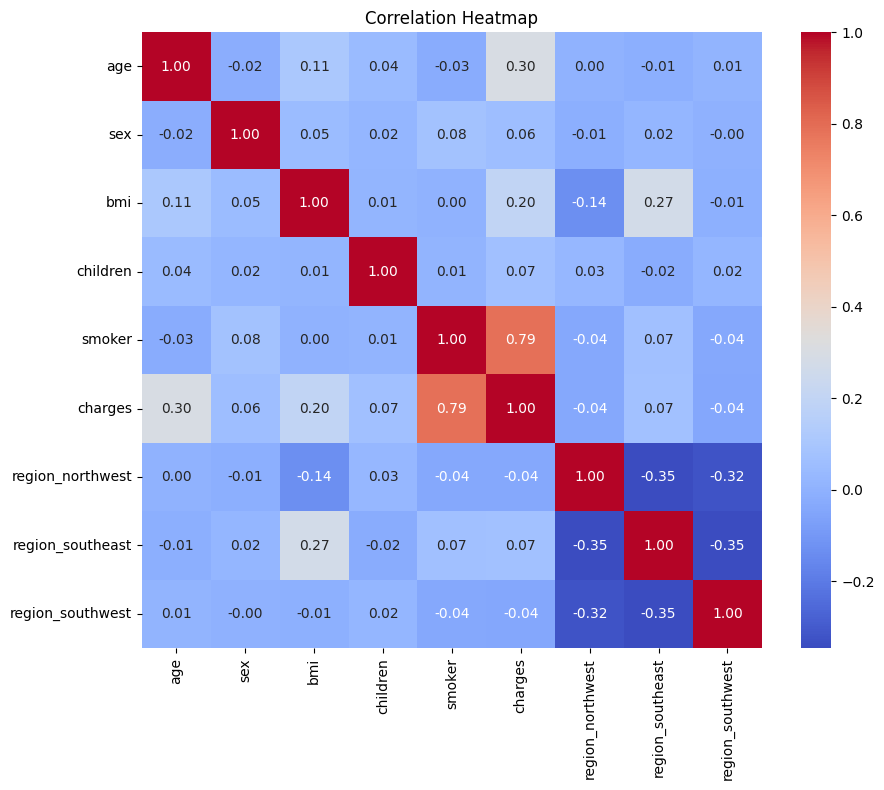

In [85]:
# Correlation Heatmap visualization code
# Create a temporary copy for correlation analysis
heatmap_df = df_copy.copy()

# Remove BMI Category created for visualization
heatmap_df = heatmap_df.drop(columns=['BMI Category'])

# Encode categorical variables
heatmap_df['sex'] = heatmap_df['sex'].map({'female':0,'male':1})
heatmap_df['smoker'] = heatmap_df['smoker'].map({'no':0,'yes':1})

heatmap_df = pd.get_dummies(
    heatmap_df,
    columns=['region'],
    drop_first=True
)

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to visualize the strength and direction of relationships between numerical variables. It helps identify which features are most strongly associated with the target variable (charges) and whether any predictors are highly correlated with each other.

##### 2. What is/are the insight(s) found from the chart?



*  Smoking status has the strongest positive correlation with insurance charges.
*  Age and BMI also show a positive correlation with medical expenses, though weaker than smoking.



#### Chart - 15 - Pair Plot

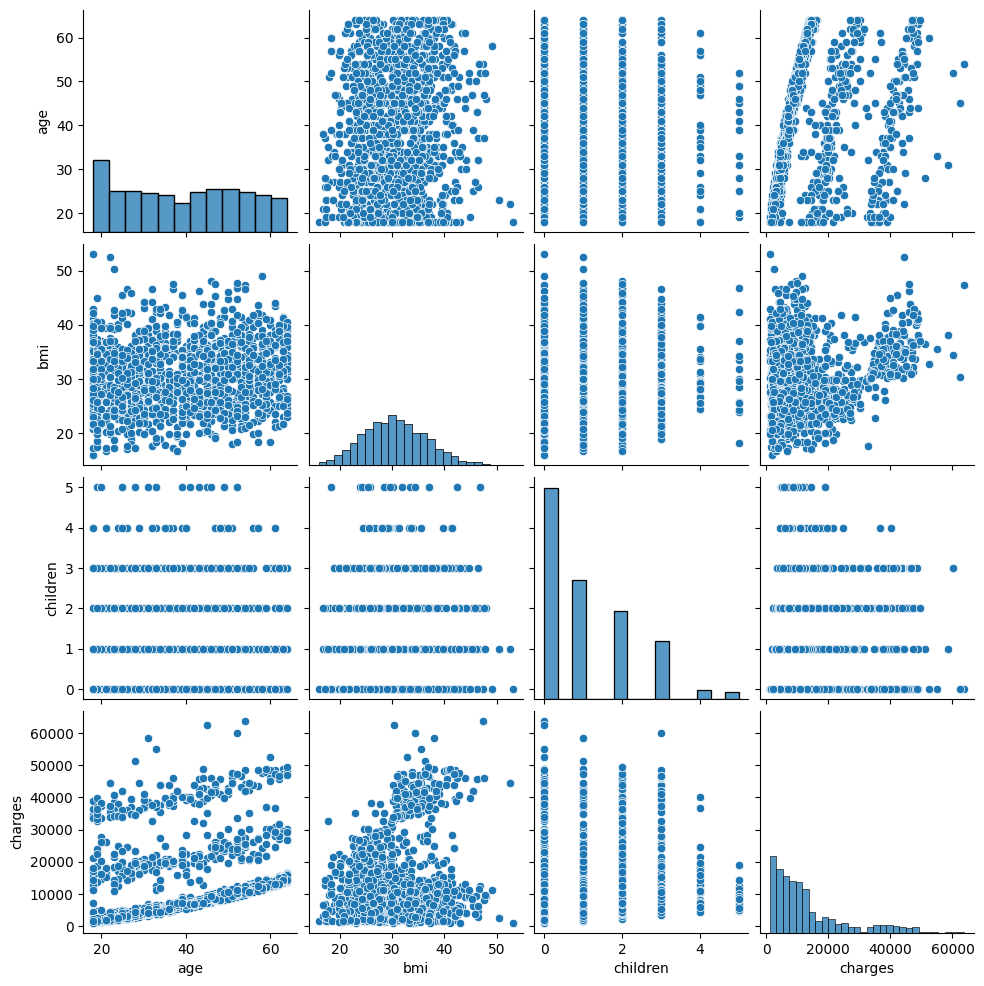

In [86]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A pair plot is used to visualize the relationships between multiple numerical variables simultaneously. It displays scatter plots for every pair of variables and the distribution of each variable along the diagonal. This helps identify trends, correlations, clusters, and potential outliers before building machine learning models.

##### 2. What is/are the insight(s) found from the chart?

Age shows a positive relationship with insurance charges, indicating that medical expenses generally increase with age.

BMI also exhibits a positive association with insurance charges, although the relationship is weaker than age.

Children has a relatively weak relationship with insurance charges.

The distribution plots reveal that charges are right-skewed, while age and BMI are more evenly distributed.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [58]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [59]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [60]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [61]:
# Expand Contraction

#### 2. Lower Casing

In [62]:
# Lower Casing

#### 3. Removing Punctuations

In [63]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [64]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [65]:
# Remove Stopwords

In [66]:
# Remove White spaces

#### 6. Rephrase Text

In [67]:
# Rephrase Text

#### 7. Tokenization

In [68]:
# Tokenization

#### 8. Text Normalization

In [69]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [70]:
# POS Taging

#### 10. Text Vectorization

In [71]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [72]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [73]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [74]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [75]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [76]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [77]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [78]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [79]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [80]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [81]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [82]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [83]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***